# Bronze layer exploration notebook

### imports and data loading

In [2]:
import pandas as pd
from config import BRONZE_DIR

# orders
latest_orders_path = sorted((BRONZE_DIR / "orders").glob("orders_*.jsonl"))[-1]
df_orders = pd.read_json(latest_orders_path, lines=True)

# products
latest_products_path = sorted((BRONZE_DIR / "products").glob("products_*.jsonl"))[-1]
df_products = pd.read_json(latest_products_path, lines=True)   

# customers
latest_customers_path = sorted((BRONZE_DIR / "customers").glob("customers_*.jsonl"))[-1]
df_customers = pd.read_json(latest_customers_path, lines=True)




### Exploring orders data

In [33]:
df_orders.head(5)

,id,name,createdAt,processedAt,displayFinancialStatus,tags,totalPriceSet,customer,lineItems
0,gid://shopify/Order/6863460728903,#1944,2026-08-07T08:43:48Z,2025-08-06T21:59:11Z,PAID,"[source:direct, synthetic]","{'shopMoney': {'amount': '389.85', 'currencyCo...",{'id': 'gid://shopify/Customer/8899950706759'},{'edges': [{'node': {'title': 'VANS | OLD SKOO...
1,gid://shopify/Order/6863063973959,#1593,2026-08-07T07:30:32Z,2025-08-06T22:26:15Z,PAID,"[source:google, synthetic]","{'shopMoney': {'amount': '649.8', 'currencyCod...",{'id': 'gid://shopify/Customer/8900800446535'},{'edges': [{'node': {'title': 'VANS | AUTHENTI...
2,gid://shopify/Order/6867039912007,#2637,2026-08-07T15:02:08Z,2025-08-07T09:44:12Z,PAID,"[source:organic, synthetic]","{'shopMoney': {'amount': '2769.65', 'currencyC...",{'id': 'gid://shopify/Customer/8901292359751'},"{'edges': [{'node': {'title': ""ASICS TIGER | G..."
3,gid://shopify/Order/6863064105031,#1594,2026-08-07T07:30:45Z,2025-08-07T10:08:20Z,PAID,"[source:direct, synthetic]","{'shopMoney': {'amount': '739.9', 'currencyCod...",{'id': 'gid://shopify/Customer/8900800544839'},{'edges': [{'node': {'title': 'PUMA | SUEDE CL...
4,gid://shopify/Order/6862370635847,#1219,2026-08-07T05:20:57Z,2025-08-07T13:08:37Z,PAID,"[source:google, synthetic]","{'shopMoney': {'amount': '1559.5', 'currencyCo...",{'id': 'gid://shopify/Customer/8894398300231'},"{'edges': [{'node': {'title': ""ASICS TIGER | G..."


In [28]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      2371 non-null   str   
 1   name                    2371 non-null   str   
 2   createdAt               2371 non-null   str   
 3   processedAt             2371 non-null   str   
 4   displayFinancialStatus  2371 non-null   str   
 5   tags                    2371 non-null   object
 6   totalPriceSet           2371 non-null   object
 7   customer                2328 non-null   object
 8   lineItems               2371 non-null   object
dtypes: object(4), str(5)
memory usage: 166.8+ KB


C:\Users\Ofek.Grossman\AppData\Local\Temp\ipykernel_2464\1568556579.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_orders.groupby(df_orders['processedAt'].dt.to_period('M')).size().plot(kind='bar', title='Orders by Processed Date Month')


<Axes: title={'center': 'Orders by Processed Date Month'}, xlabel='processedAt'>

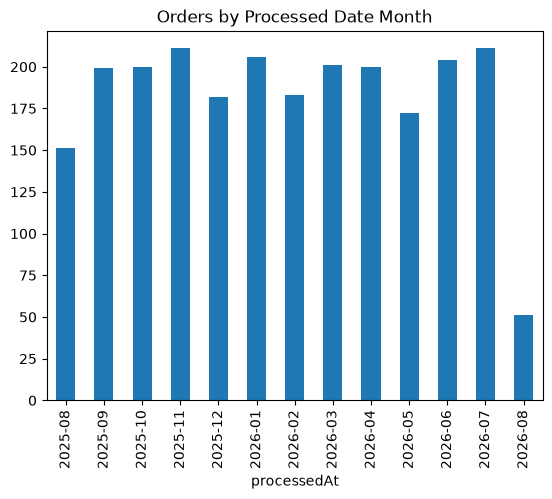

In [5]:
df_orders['processedAt'] = pd.to_datetime(df_orders['processedAt'])
df_orders.groupby(df_orders['processedAt'].dt.to_period('M')).size().plot(kind='bar', title='Orders by Processed Date Month')

### Exploring products data

In [6]:
df_products.head(5)

,id,title,productType,vendor,tags,status,createdAt
0,gid://shopify/Product/7623609647175,The Inventory Not Tracked Snowboard,snowboard,ofek-dev-store,"[Accessory, Sport, Winter]",ACTIVE,2026-08-05T18:31:42Z
1,gid://shopify/Product/7623609679943,Gift Card,giftcard,Snowboard Vendor,[],ACTIVE,2026-08-05T18:31:42Z
2,gid://shopify/Product/7623609778247,The Compare at Price Snowboard,snowboard,ofek-dev-store,"[Accessory, Sport, Winter]",ACTIVE,2026-08-05T18:31:42Z
3,gid://shopify/Product/7623609811015,The Archived Snowboard,snowboard,Snowboard Vendor,"[Archived, Premium, Snow, Snowboard, Sport, Wi...",ARCHIVED,2026-08-05T18:31:42Z
4,gid://shopify/Product/7623609843783,The Draft Snowboard,snowboard,Snowboard Vendor,[],DRAFT,2026-08-05T18:31:42Z


In [7]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           47 non-null     str   
 1   title        47 non-null     str   
 2   productType  47 non-null     str   
 3   vendor       47 non-null     str   
 4   tags         47 non-null     object
 5   status       47 non-null     str   
 6   createdAt    47 non-null     str   
dtypes: object(1), str(6)
memory usage: 2.7+ KB


<Axes: title={'center': 'Products by Product Type'}, xlabel='productType'>

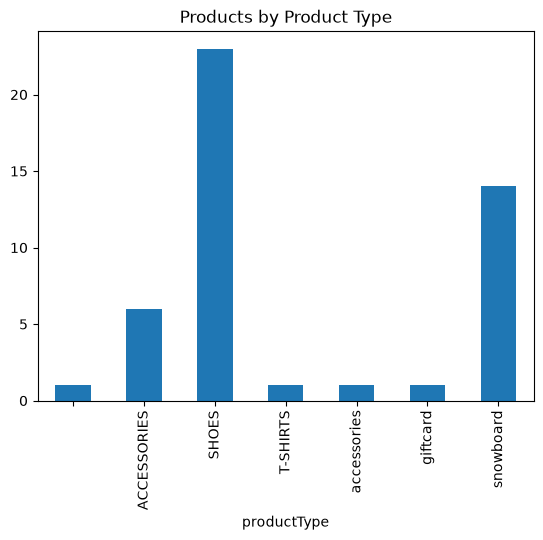

In [9]:
df_products.groupby('productType').size().plot(kind='bar', title='Products by Product Type')

<Axes: title={'center': 'Products by Vendor'}, xlabel='vendor'>

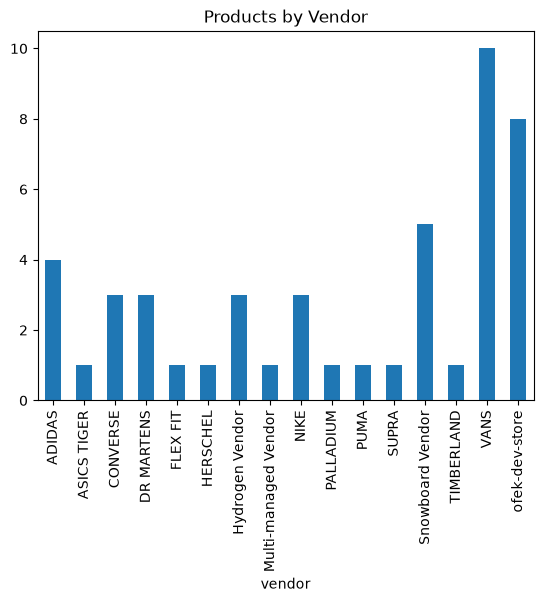

In [10]:
df_products.groupby('vendor').size().plot(kind='bar', title='Products by Vendor')

### Exploring customers data

In [11]:
df_customers.head(5)

,id,createdAt,numberOfOrders,defaultAddress
0,gid://shopify/Customer/8885403746375,2026-08-05T18:31:42Z,8,None
1,gid://shopify/Customer/8885403779143,2026-08-05T18:31:42Z,9,"{'city': 'Toronto', 'country': 'Canada'}"
2,gid://shopify/Customer/8885403811911,2026-08-05T18:31:42Z,10,"{'city': 'Ottawa', 'country': 'Canada'}"
3,gid://shopify/Customer/8894398070855,2026-08-06T09:32:18Z,10,"{'city': '13', 'country': 'France'}"
4,gid://shopify/Customer/8894398103623,2026-08-06T09:32:20Z,9,"{'city': 'Barcelona', 'country': 'Spain'}"


In [2]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              919 non-null    str   
 1   createdAt       919 non-null    str   
 2   numberOfOrders  919 non-null    int64 
 3   defaultAddress  12 non-null     object
dtypes: int64(1), object(1), str(2)
memory usage: 28.8+ KB


<Axes: title={'center': 'Top 10 Customers by Number of Orders'}, xlabel='id'>

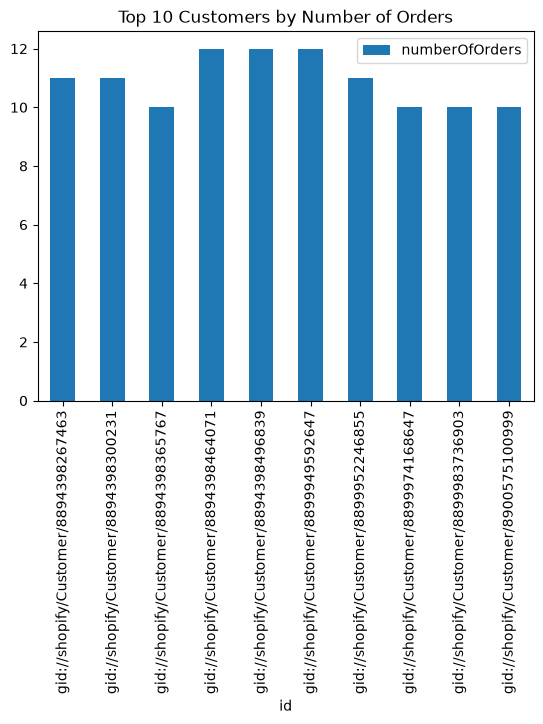

In [5]:
top_10_customers = df_customers.sort_values(by='numberOfOrders', ascending=False).head(10)
top_10_customers.groupby('id').agg({'numberOfOrders': 'sum'}).plot(kind='bar', title='Top 10 Customers by Number of Orders')